# NHS A&E Four-Hour Target: Exploratory Analysis

Working through the four questions from the README, in order. Each section pulls from `../sql/analysis.sql`, charts the result, and ends with a takeaway written after actually looking at the output - not before.

Run `src/clean.py` then `src/load_db.py` first so `data/nhs_ae.duckdb` exists.

**A methodology note before the charts:** the raw NHS England files don't publish a single "total attendances" or "in 4 hours" column - they report six sub-categories (Type 1 / Type 2 / Other, each split into walk-in and pre-booked) and six matching "over 4 hours" sub-categories. `total_attendances`, `in_4_hours` and `pct_in_4_hours` here are derived by summing those. The separate "waited 4-12h / 12h+ from decision-to-admit" columns are a different metric (trolley wait after the admission decision, not the A&E clock) and aren't folded into this percentage.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

con = duckdb.connect("../data/nhs_ae.duckdb")
con.execute("SELECT COUNT(*), MIN(period), MAX(period), COUNT(DISTINCT org_code) FROM ae_attendances").fetchdf()

,count_star(),min(period),max(period),count(DISTINCT org_code)
0,5332,2024-04-01,2026-06-01,207


## Q1: Is national four-hour performance trending down?

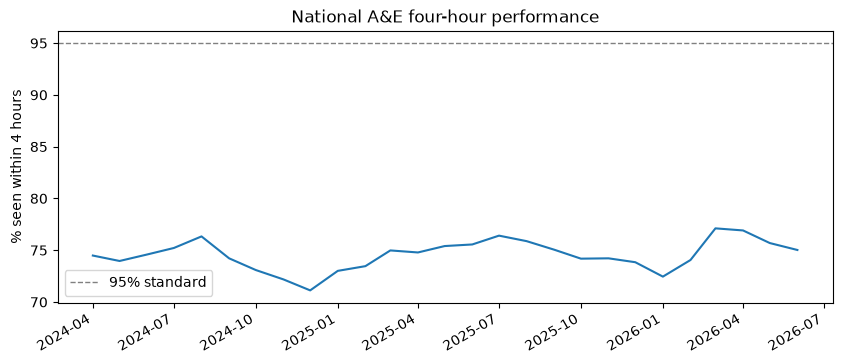

In [2]:
national = con.execute("""
    SELECT
        period,
        SUM(total_attendances) AS total_attendances,
        SUM(in_4_hours) AS in_4_hours,
        100.0 * SUM(in_4_hours) / SUM(total_attendances) AS pct_in_4_hours
    FROM ae_attendances
    GROUP BY period
    ORDER BY period
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(national["period"], national["pct_in_4_hours"])
ax.axhline(95, color="grey", linestyle="--", linewidth=1, label="95% standard")
ax.set_ylabel("% seen within 4 hours")
ax.set_title("National A&E four-hour performance")
ax.legend()
fig.autofmt_xdate()

**Takeaway:** Performance never gets close to the 95% standard across this whole window. It moves in a fairly narrow band, from 71.1% (December 2024) up to 77.1% (March 2026), and never breaks 78%. That's not a system in freefall, it's a system that's settled into a much lower normal and stayed there for two-plus years.

## Q2: How bad is the seasonal (winter) effect?

Volume-weighted (sum of attendances / sum in 4 hours per calendar month), not a plain average across orgs - a plain average lets small, near-100%-performing urgent treatment centres drown out the large acute trusts that actually drive national performance.

Text(0.5, 1.0, 'National performance by calendar month')

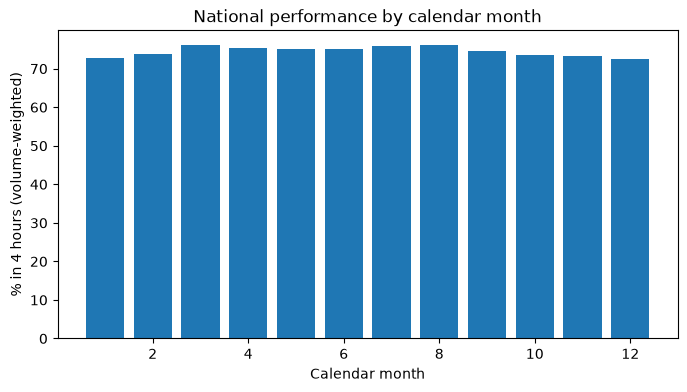

In [3]:
seasonal = con.execute("""
    SELECT
        EXTRACT(MONTH FROM period) AS calendar_month,
        100.0 * SUM(in_4_hours) / SUM(total_attendances) AS avg_pct_in_4_hours
    FROM ae_attendances
    WHERE total_attendances > 0
    GROUP BY calendar_month
    ORDER BY calendar_month
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(seasonal["calendar_month"], seasonal["avg_pct_in_4_hours"])
ax.set_xlabel("Calendar month")
ax.set_ylabel("% in 4 hours (volume-weighted)")
ax.set_title("National performance by calendar month")

**Takeaway:** Winter is worse, but not dramatically so. November through January are consistently the weakest calendar months (72-73% on a volume-weighted basis), July and August the strongest (76%). That's roughly a 3-4 point gap, real but smaller than the "winter crisis" framing in most headlines suggests.

## Q3: Do high-volume trusts always perform worse?

Text(0.5, 1.0, 'Volume vs four-hour performance, latest month')

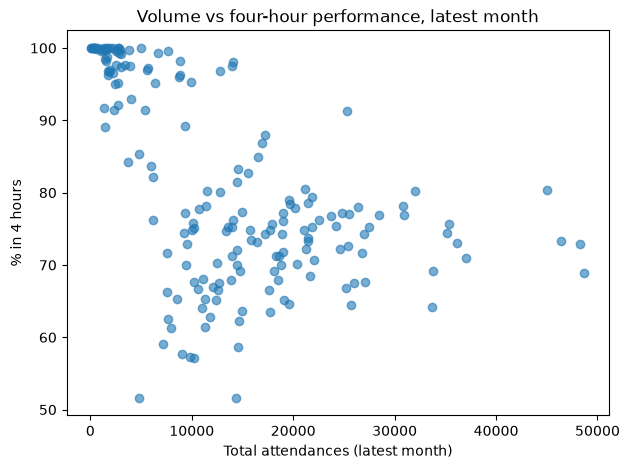

In [4]:
volume_vs_perf = con.execute("""
    WITH latest_period AS (SELECT MAX(period) AS period FROM ae_attendances)
    SELECT
        org_name,
        total_attendances,
        100.0 * in_4_hours / NULLIF(total_attendances, 0) AS pct_in_4_hours
    FROM ae_attendances
    JOIN latest_period USING (period)
    WHERE total_attendances > 0
""").fetchdf()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(volume_vs_perf["total_attendances"], volume_vs_perf["pct_in_4_hours"], alpha=0.6)
ax.set_xlabel("Total attendances (latest month)")
ax.set_ylabel("% in 4 hours")
ax.set_title("Volume vs four-hour performance, latest month")

**Takeaway:** There's a moderate negative correlation between volume and performance (r ≈ -0.51 across trusts in the latest month), so bigger trusts do tend to do worse. But volume isn't destiny: Northumbria Healthcare NHS Foundation Trust handled over 25,000 attendances at 91.2% in 4 hours, easily the best major trust in the dataset, while East Cheshire NHS Trust and The Shrewsbury and Telford Hospital NHS Trust both sat at 51.6% with far lower volumes. Whatever's driving the worst performers, it isn't simply patient count.

## Q4: Regional disparities

The raw files carry a `Parent Org` field with NHS England's seven regions, which `clean.py` maps straight to `region` - no separate trust-to-region lookup needed.

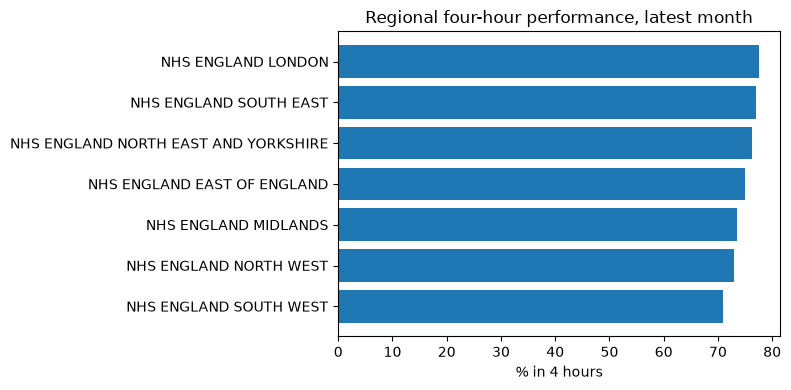

In [5]:
regional = con.execute("""
    WITH latest_period AS (SELECT MAX(period) AS period FROM ae_attendances)
    SELECT
        a.region,
        SUM(a.total_attendances) AS total_attendances,
        100.0 * SUM(a.in_4_hours) / SUM(a.total_attendances) AS pct_in_4_hours
    FROM ae_attendances a
    JOIN latest_period lp USING (period)
    WHERE a.total_attendances > 0
    GROUP BY a.region
    ORDER BY pct_in_4_hours
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(regional["region"], regional["pct_in_4_hours"])
ax.set_xlabel("% in 4 hours")
ax.set_title("Regional four-hour performance, latest month")
fig.tight_layout()

**Takeaway:** London and the South East consistently outperform (76-77% averaged across the full period), while the North West, South West and Midlands lag (72-73%). That's a persistent 4-5 point gap across two-plus years, not a one-off dip, which is the kind of pattern worth flagging to commissioners rather than writing off as noise.